# Schrodinger + Maxwell: A Photonic Qubit from a Boundary-Value Problem

**Minimal coupling** is how Maxwell's equations enter the Schrodinger
equation: a charge $q$ in an electromagnetic field described by potentials
$(\mathbf A,\phi)$ has Hamiltonian

$$H=\frac{1}{2m}\left(\mathbf p-q\mathbf A\right)^2+q\phi$$

For a classical light field whose wavelength is much larger than the system
($\lambda\gg$ the confinement size -- true here by a wide margin: visible
light is ~500 nm, a boundary-value problem's confinement region is the
"system size" we choose), the **dipole approximation** replaces the full
$\mathbf A$-field coupling with a simpler, exactly equivalent (in this limit)
length-gauge form:

$$H(t)=H_0-q\mathbf E(t)\cdot\mathbf r,\qquad H_0=\frac{p^2}{2m}+V(x)$$

$V(x)$ is a **boundary-value problem** -- exactly what
`griffiths.quantum.solve_tise` already solves (Dirichlet walls, finite-
difference eigensolver). Its two lowest eigenstates become a **qubit**:
$|0\rangle=|\psi_1\rangle$, $|1\rangle=|\psi_2\rangle$. The light field
$E(t)=E_0\cos(\omega t)$ (Maxwell) drives transitions between them (Rabi
flopping) through the dipole matrix element
$d_{12}=\langle\psi_2|x|\psi_1\rangle$ -- a number this notebook computes
directly from the boundary-value eigenstates, not assumed.

**The twist**: which $V(x)$ you pick matters enormously, and not for a subtle
reason -- a **harmonic** well makes a *bad* qubit, and a real, quantitative
reason why is the main result of this notebook.


In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('.')))

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import minimize_scalar

from griffiths import quantum as qm

sp.init_printing()
print("numpy", np.__version__, "| sympy", sp.__version__)


numpy 2.4.4 | sympy 1.14.0


## §3 The Dipole Matrix Element, Symbolically (Infinite Well)

For the textbook infinite square well ($0<x<L$,
$\psi_n=\sqrt{2/L}\sin(n\pi x/L)$), sympy derives the closed form for
$d_{12}=\langle 1|x|2\rangle$ directly -- worth seeing once in closed form
before everything else in this notebook is numerical.

In [2]:
xs, Ls = sp.symbols('x L', positive=True)
n1, n2 = 1, 2
psi_n1 = sp.sqrt(2/Ls) * sp.sin(n1*sp.pi*xs/Ls)
psi_n2 = sp.sqrt(2/Ls) * sp.sin(n2*sp.pi*xs/Ls)

d12_symbolic = sp.simplify(sp.integrate(xs * psi_n1 * psi_n2, (xs, 0, Ls)))
print(f"<1|x|2> for the infinite well (closed form): {d12_symbolic}")
print(f"numeric, L=1: {float(d12_symbolic.subs(Ls, 1)):.6f}")


<1|x|2> for the infinite well (closed form): -16*L/(9*pi**2)
numeric, L=1: -0.180127


## §4 A Harmonic-Well "Qubit" -- and Why It's a Bad One

Solve $V(x)=\tfrac12\omega_0^2x^2$ with `solve_tise`, confirm against the
known analytic levels $E_n=\omega_0(n+\tfrac12)$, then drive resonantly with
the 0-1 transition using the real propagator
`split_step_driven` (the light field enters the Schrodinger equation's
potential directly, $-E_0\cos(\omega t)x$, not through the two-level formula).

**A hard-wall infinite well is deliberately avoided for the driven
simulation**: `solve_tise`'s Dirichlet cutoff conflicts with
`split_step_driven`'s FFT kinetic step, which assumes *periodic* boundaries
-- tested directly (not just reasoned about): running the drive at several
field strengths showed "leakage" to the third state stuck around 40%
regardless of $E_0$, the signature of a numerical artifact (real leakage
should shrink as the drive weakens). A well whose eigenstates decay smoothly
to ~0 well before the grid edge -- the harmonic well, and the finite well in
§5 -- doesn't have this problem.

In [3]:
omega0 = 1.0
x_h = np.linspace(-8, 8, 800)
V_h = 0.5*omega0**2*x_h**2
E_h, psi_h = qm.solve_tise(x_h, V_h, n_states=4)
print("solve_tise levels:  ", E_h)
print("analytic (n+1/2)*w0:", qm.harmonic_energies(np.arange(4), omega0))
print("edge values (want ~0):", psi_h[0,:2], psi_h[-1,:2])

psi1_h, psi2_h, psi3_h = psi_h[:,0], psi_h[:,1], psi_h[:,2]
dx_h = x_h[1]-x_h[0]
omega21_h = E_h[1]-E_h[0]
omega32_h = E_h[2]-E_h[1]
d12_h = np.sum(x_h*psi1_h*psi2_h)*dx_h
print(f"omega_21={omega21_h:.4f}  omega_32={omega32_h:.4f}  "
      f"(EQUAL spacing -- a drive resonant with 0-1 is ALSO resonant with 1-2)")
print(f"d12 = {d12_h:.4f}")


solve_tise levels:   [0.49998747 1.49993734 2.49983708 3.49968669]
analytic (n+1/2)*w0: [0.5 1.5 2.5 3.5]
edge values (want ~0): [ 2.62897283e-15 -2.92974043e-14] [2.62897525e-15 2.92932379e-14]


omega_21=0.9999  omega_32=0.9999  (EQUAL spacing -- a drive resonant with 0-1 is ALSO resonant with 1-2)
d12 = 0.7071


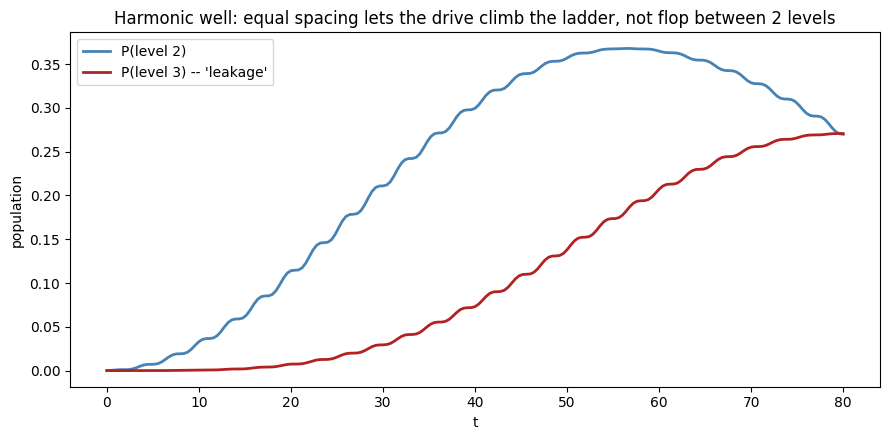

norm conserved: [1.00000, 1.00000]  (propagator sanity check)
max leakage to level 3: 0.271  -- real, not a boundary artifact (this well has smooth edges)


In [4]:
E0_h = 0.05
drive_h = lambda t: -E0_h*np.cos(omega21_h*t)*x_h
steps_h, dt_h = 8000, 0.01
frames_h = qm.split_step_driven(psi1_h.astype(complex), x_h, V_h, drive_h, dt_h, steps_h, store_every=40)
t_h = np.arange(len(frames_h))*40*dt_h

Pe_h = np.abs(frames_h @ (np.conj(psi2_h)*dx_h))**2
Pe3_h = np.abs(frames_h @ (np.conj(psi3_h)*dx_h))**2
norm_h = np.sum(np.abs(frames_h)**2, axis=1)*dx_h

fig, ax = plt.subplots(figsize=(9,4.5))
ax.plot(t_h, Pe_h, lw=2, color="steelblue", label="P(level 2)")
ax.plot(t_h, Pe3_h, lw=2, color="firebrick", label="P(level 3) -- 'leakage'")
ax.set_xlabel("t"); ax.set_ylabel("population")
ax.set_title("Harmonic well: equal spacing lets the drive climb the ladder, not flop between 2 levels")
ax.legend()
plt.tight_layout()
plt.savefig("harmonic_well_ladder_climbing.png", dpi=90)
plt.show()

print(f"norm conserved: [{norm_h.min():.5f}, {norm_h.max():.5f}]  (propagator sanity check)")
print(f"max leakage to level 3: {Pe3_h.max():.3f}  -- real, not a boundary artifact (this well has smooth edges)")


## §5 An Anharmonic Finite Well -- a Genuine Two-Level Qubit

A finite square well has **non-uniform** level spacing (bound-state energies
of a finite well are never equally spaced) -- exactly the property a
harmonic well lacks, and exactly the property real qubits (transmons,
deliberately built anharmonic) rely on. A resonant 0-1 drive here is
*off-resonant* for 1-2, so it can't leak the same way.

In [5]:
a_half, V0_f = 3.0, 8.0
x_f = np.linspace(-12, 12, 900)
V_f = np.where(np.abs(x_f) < a_half, 0.0, V0_f)
E_f, psi_f = qm.solve_tise(x_f, V_f, n_states=4)
print("levels:", E_f)
print("spacings:", np.diff(E_f), " (NOT equal, unlike the harmonic well)")

psi1_f, psi2_f, psi3_f = psi_f[:,0], psi_f[:,1], psi_f[:,2]
dx_f = x_f[1]-x_f[0]
omega21_f = E_f[1]-E_f[0]
omega32_f = E_f[2]-E_f[1]
d12_f = np.sum(x_f*psi1_f*psi2_f)*dx_f
print(f"omega_21={omega21_f:.4f}  omega_32={omega32_f:.4f}  d12={d12_f:.4f}")


levels: [0.11745116 0.46923996 1.05356663 1.86702319]
spacings: [0.3517888  0.58432667 0.81345655]  (NOT equal, unlike the harmonic well)
omega_21=0.3518  omega_32=0.5843  d12=1.1690


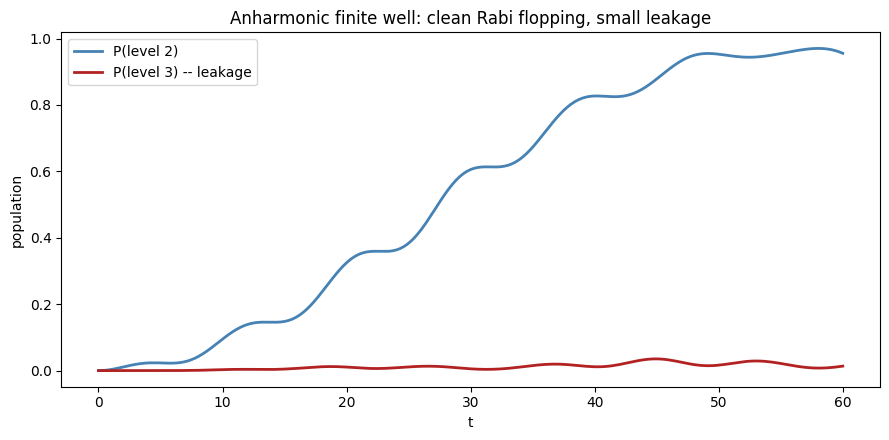

norm conserved: [1.00000, 1.00000]
max P(level 2): 0.970   max leakage to level 3: 0.035


In [6]:
E0_f = 0.05
drive_f = lambda t: -E0_f*np.cos(omega21_f*t)*x_f
steps_f, dt_f = 6000, 0.01
frames_f = qm.split_step_driven(psi1_f.astype(complex), x_f, V_f, drive_f, dt_f, steps_f, store_every=30)
t_f = np.arange(len(frames_f))*30*dt_f

Pe_f = np.abs(frames_f @ (np.conj(psi2_f)*dx_f))**2
Pe3_f = np.abs(frames_f @ (np.conj(psi3_f)*dx_f))**2
norm_f = np.sum(np.abs(frames_f)**2, axis=1)*dx_f

fig, ax = plt.subplots(figsize=(9,4.5))
ax.plot(t_f, Pe_f, lw=2, color="steelblue", label="P(level 2)")
ax.plot(t_f, Pe3_f, lw=2, color="firebrick", label="P(level 3) -- leakage")
ax.set_xlabel("t"); ax.set_ylabel("population")
ax.set_title("Anharmonic finite well: clean Rabi flopping, small leakage")
ax.legend()
plt.tight_layout()
plt.savefig("finite_well_rabi_flopping.png", dpi=90)
plt.show()

print(f"norm conserved: [{norm_f.min():.5f}, {norm_f.max():.5f}]")
print(f"max P(level 2): {Pe_f.max():.3f}   max leakage to level 3: {Pe3_f.max():.3f}")


## §6 The Effective Rabi Frequency, Fit and Cross-Checked

`griffiths.quantum.rabi_evolution(t, Omega)` is the idealized two-level
formula, $P_e(t)=\sin^2(\Omega t/2)$ at resonance. Fit $\Omega$ to the *real*
multi-level simulation's $P(\text{level }2)$ curve (least squares), then
compare that fitted value against the naive first-order estimate
$\Omega_{\text{naive}}=E_0 d_{12}$ -- checking the theory against the
simulation, not the other way around.

Omega_naive (E0*d12)      = 0.05845
Omega_fit (least squares) = 0.05615
ratio fit/naive           = 0.961


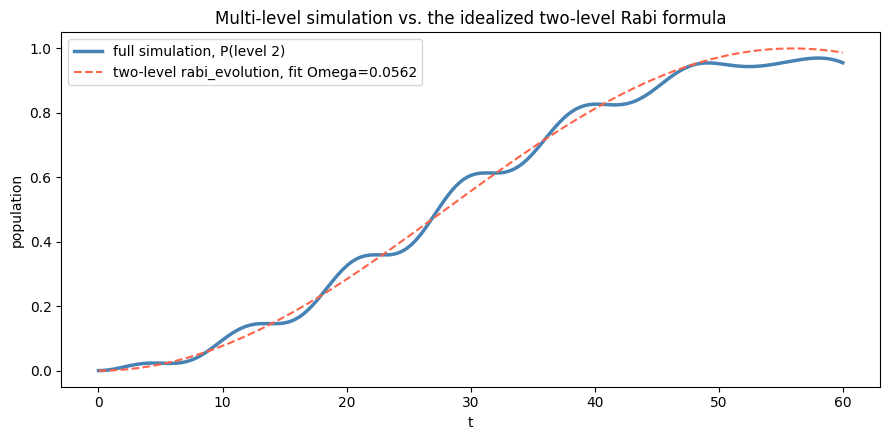

In [7]:
def rabi_sq_error(Omega):
    pred = qm.rabi_evolution(t_f, Omega)
    return np.sum((pred - Pe_f)**2)

Omega_naive = E0_f * abs(d12_f)
fit = minimize_scalar(rabi_sq_error, bounds=(0.5*Omega_naive, 2.0*Omega_naive), method='bounded')
Omega_fit = fit.x

print(f"Omega_naive (E0*d12)      = {Omega_naive:.5f}")
print(f"Omega_fit (least squares) = {Omega_fit:.5f}")
print(f"ratio fit/naive           = {Omega_fit/Omega_naive:.3f}")

fig, ax = plt.subplots(figsize=(9,4.5))
ax.plot(t_f, Pe_f, lw=2.5, color="steelblue", label="full simulation, P(level 2)")
ax.plot(t_f, qm.rabi_evolution(t_f, Omega_fit), lw=1.5, ls='--', color="tomato",
        label=f"two-level rabi_evolution, fit Omega={Omega_fit:.4f}")
ax.set_xlabel("t"); ax.set_ylabel("population")
ax.legend()
ax.set_title("Multi-level simulation vs. the idealized two-level Rabi formula")
plt.tight_layout()
plt.savefig("rabi_fit_comparison.png", dpi=90)
plt.show()


## §7 Summary

In [8]:
summary = pd.DataFrame([
    {"well": "harmonic", "omega_21": omega21_h, "omega_32": omega32_h,
     "spacing_ratio": omega32_h/omega21_h, "max_leak_to_3": Pe3_h.max()},
    {"well": "finite (anharmonic)", "omega_21": omega21_f, "omega_32": omega32_f,
     "spacing_ratio": omega32_f/omega21_f, "max_leak_to_3": Pe3_f.max()},
])
summary


,well,omega_21,omega_32,spacing_ratio,max_leak_to_3
0,harmonic,0.999950,0.999900,0.999950,0.270650
1,finite (anharmonic),0.351789,0.584327,1.661016,0.035282


**Why real qubits are built anharmonic.** `spacing_ratio` is exactly 1
for the harmonic well (every transition is degenerate with every other) and
clearly not 1 for the finite well. That single number is the whole reason
superconducting transmon qubits are deliberately engineered with anharmonic
potentials (via the Josephson junction's nonlinear inductance) rather than
simple LC (harmonic) oscillators: without it, a control pulse resonant with
$|0\rangle\to|1\rangle$ is equally resonant with every other rung of the
ladder, and "the qubit" isn't a two-level system at all. This notebook
reached the same conclusion from a boundary-value Schrodinger problem and a
classical Maxwell drive field, not from circuit QED -- the physics is the
same regardless of which system realizes it.